# Import modules

In [47]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Model PINN

In [48]:
class ArticleLikeTLFN(nn.Module):
    """
    Двухслойная feedforward-сеть в форме, близкой к статье
    Guliyev, Ismailov.

    Для d=2:
        f_hat(x1, x2) = sum_p e_p * sigma(
            c_p1 * sigma(x1 - theta_p1)
          + c_p2 * sigma(x2 - theta_p2)
          - zeta_p
        )
    """
    def __init__(self, input_size=2, output_size=1):
        super().__init__()

        self.d = input_size
        self.m = 2 * self.d + 2  # второй скрытый слой: 2d + 2

        self.theta = nn.Parameter(torch.zeros(self.m, self.d))
        self.c = nn.Parameter(torch.randn(self.m, self.d))

        self.zeta = nn.Parameter(torch.zeros(self.m))
        self.e = nn.Parameter(torch.randn(self.m, output_size))

    def sigma(self, x):
        return torch.sigmoid(x)

    def forward(self, x):
        # x: [batch, d]

        # h_{p,q} = sigma(x_q - theta_{p,q})
        h = self.sigma(x[:, None, :] - self.theta[None, :, :])
        # h: [batch, m, d]

        # z_p = sigma(sum_q c_{p,q} h_{p,q} - zeta_p)
        z = self.sigma((self.c[None, :, :] * h).sum(dim=-1) - self.zeta[None, :])
        # z: [batch, m]

        # y = sum_p e_p z_p
        y = z @ self.e
        # y: [batch, output_size]

        return y

# Задача Дирихле для уравнения Пуассона 

Рассмотрим задачу Дирихле для уравнения Пуассона на квадрате $\quad (x, y) \in [0, \frac{\pi}{2}] × [0, \frac{\pi}{2}]$:

$$
\begin{cases}
u_{xx} + u_{yy} = -5\sin(x)\cos(2y),  \\
u(0,y) = 0, \\
u(\frac{\pi}{2},y) = \cos(2y), \\
u(x,0) = \sin(x), \\
u(x, \frac{\pi}{2}) = -\sin(x).
\end{cases}
$$

Для данной начальной формы точное решение имеет вид:

$$
u(x,y) = \sin(x) \cos(2y).
$$

In [49]:
# ============================================================
# Параметры задачи Дирихле
# ============================================================

L = torch.pi / 2

N_f = 1000   # точки внутри области для eq residual
N_b = 100    # точки на каждой стороне границы

# ============================================================
# Внутренние точки области
# x, y in (0, pi/2)
# ============================================================

x_f = L * torch.rand(N_f, 1).to(device)
y_f = L * torch.rand(N_f, 1).to(device)

xy_f = torch.cat([x_f, y_f], dim=1)
xy_f.requires_grad_(True)

# ============================================================
# Граничные условия
#
# u(0, y)       = 0
# u(pi/2, y)    = cos(2y)
# u(x, 0)       = sin(x)
# u(x, pi/2)    = -sin(x)
# ============================================================

grid_b = torch.linspace(0, L, N_b).unsqueeze(1).to(device)

# Левая граница: x = 0
y_left = grid_b
x_left = torch.zeros_like(y_left)
xy_b_left = torch.cat([x_left, y_left], dim=1)
u_b_left_true = torch.zeros_like(y_left)

# Правая граница: x = pi/2
y_right = grid_b
x_right = L * torch.ones_like(y_right)
xy_b_right = torch.cat([x_right, y_right], dim=1)
u_b_right_true = torch.cos(2 * y_right)

# Нижняя граница: y = 0
x_bottom = grid_b
y_bottom = torch.zeros_like(x_bottom)
xy_b_bottom = torch.cat([x_bottom, y_bottom], dim=1)
u_b_bottom_true = torch.sin(x_bottom)

# Верхняя граница: y = pi/2
x_top = grid_b
y_top = L * torch.ones_like(x_top)
xy_b_top = torch.cat([x_top, y_top], dim=1)
u_b_top_true = -torch.sin(x_top)

# Собираем все граничные точки вместе
xy_b = torch.cat(
    [xy_b_left, xy_b_right, xy_b_bottom, xy_b_top],
    dim=0
)

u_b_true = torch.cat(
    [u_b_left_true, u_b_right_true, u_b_bottom_true, u_b_top_true],
    dim=0
)

In [50]:
def eq(out, xy):

    # Первая производная: grad_u = [u_x, u_y]
    grad_u = torch.autograd.grad(
        out,
        xy,
        torch.ones_like(out),
        create_graph=True,
        retain_graph=True
    )[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    # Вторая производная по x: u_xx
    grad_u_x = torch.autograd.grad(
        outputs=u_x,
        inputs=xy,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]
    
    u_xx = grad_u_x[:, 0:1]

    # Вторая производная по y: u_yy
    grad_u_y = torch.autograd.grad(
        outputs=u_y,
        inputs=xy,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
        retain_graph=True
    )[0]

    u_yy = grad_u_y[:, 1:2]

    # Невязка 
    return u_xx + u_yy + 5 * torch.sin(xy[:, 0:1]) * torch.cos(2*xy[:, 1:2])

In [51]:
# Точное решение задачи
def exact_solution(xy):
    return torch.sin(xy[:, 0:1]) * torch.cos(2 *  xy[:, 1:2])

# Parameters of the task

In [52]:
def eqBC(
    model,
    xy_f,
    xy_b_left,
    xy_b_right,
    xy_b_bottom,
    xy_b_top,
    u_b_left_true,
    u_b_right_true,
    u_b_bottom_true,
    u_b_top_true,
    w_bc=1e3,
    w_eq=1.0
):
    # ============================================================
    # 1. eq loss
    # ============================================================

    # Важно: для вычисления u_xx и u_yy нужен requires_grad=True
    if not xy_f.requires_grad:
        xy_f = xy_f.clone().detach().requires_grad_(True)

    # Предсказание модели во внутренних точках области
    u_f_pred = model(xy_f)

    # Невязка задачи Пуассона:
    # u_xx + u_yy + 5 sin(x) cos(2y)
    f_residual = eq(u_f_pred, xy_f)

    loss_eq = metric_data(
        f_residual,
        torch.zeros_like(f_residual)
    )

    # ============================================================
    # 2. Boundary loss
    # ============================================================

    u_b_left_pred = model(xy_b_left)
    u_b_right_pred = model(xy_b_right)
    u_b_bottom_pred = model(xy_b_bottom)
    u_b_top_pred = model(xy_b_top)

    loss_bc_left = metric_data(u_b_left_pred, u_b_left_true)
    loss_bc_right = metric_data(u_b_right_pred, u_b_right_true)
    loss_bc_bottom = metric_data(u_b_bottom_pred, u_b_bottom_true)
    loss_bc_top = metric_data(u_b_top_pred, u_b_top_true)

    loss_bc = (
        loss_bc_left
        + loss_bc_right
        + loss_bc_bottom
        + loss_bc_top
    )

    # ============================================================
    # 3. Diagnostic metric against exact solution
    # ============================================================

    with torch.no_grad():
        u_f_true = exact_solution(xy_f)
        metric_u = metric_data(u_f_pred.detach(), u_f_true)

    # ============================================================
    # 4. Total loss
    # ============================================================

    loss = w_bc * loss_bc + w_eq * loss_eq

    metrics = {
        "loss": loss,
        "loss_bc": loss_bc,
        "loss_bc_left": loss_bc_left,
        "loss_bc_right": loss_bc_right,
        "loss_bc_bottom": loss_bc_bottom,
        "loss_bc_top": loss_bc_top,
        "loss_eq": loss_eq,
        "metric_u": metric_u,
    }

    return loss, metrics

In [73]:
steps=300

# Создаем модель 
model = ArticleLikeTLFN().to(device)

# Мрогресс-бар
pbar = tqdm(range(steps), desc='Training Progress')

# Метрика и оптимизатор 
metric_data = nn.MSELoss()
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.1,
    max_iter=20,
    history_size=100,
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer.zero_grad(set_to_none=True)
    loss, metrics = eqBC(
        model=model,
        xy_f=xy_f,
        xy_b_left=xy_b_left,
        xy_b_right=xy_b_right,
        xy_b_bottom=xy_b_bottom,
        xy_b_top=xy_b_top,
        u_b_left_true=u_b_left_true,
        u_b_right_true=u_b_right_true,
        u_b_bottom_true=u_b_bottom_true,
        u_b_top_true=u_b_top_true,
        w_bc=1e3,
        w_eq=10.0
    )
    loss.backward()
    return loss

def train():
    history = []
    for step in pbar:
        
        optimizer.step(closure)

        loss_eval, metrics_eval = eqBC(
            model=model,
            xy_f=xy_f,
            xy_b_left=xy_b_left,
            xy_b_right=xy_b_right,
            xy_b_bottom=xy_b_bottom,
            xy_b_top=xy_b_top,
            u_b_left_true=u_b_left_true,
            u_b_right_true=u_b_right_true,
            u_b_bottom_true=u_b_bottom_true,
            u_b_top_true=u_b_top_true,
            w_bc=1e3,
            w_eq=10.0
        )

        # Сохраняем detached-значения, чтобы не хранить граф вычислений
        history.append({
            name: value.detach().cpu().item()
            for name, value in metrics_eval.items()
        })

        if step % 2 == 0:
            pbar.set_description(
                "Step: %d | Loss: %.6e | eq: %.6e | BC: %.6e | Error: %.6e"
                % (
                    step,
                    metrics_eval["loss"].item(),
                    metrics_eval["loss_eq"].item(),
                    metrics_eval["loss_bc"].item(),
                    metrics_eval["metric_u"].item()
                )
            )

    return history

metrics = train()

Step: 298 | Loss: 1.795130e+00 | eq: 1.630963e-01 | BC: 1.641669e-04 | Error: 5.295859e-05: 100%|██████████| 300/300 [01:18<00:00,  3.82it/s]


In [74]:
loss = []
loss_bc = []
loss_eq = []

for step in metrics:
    loss.append(step['loss']) 
    loss_bc.append(step['loss_bc'])
    loss_eq.append(step['loss_eq'])

# Predict values

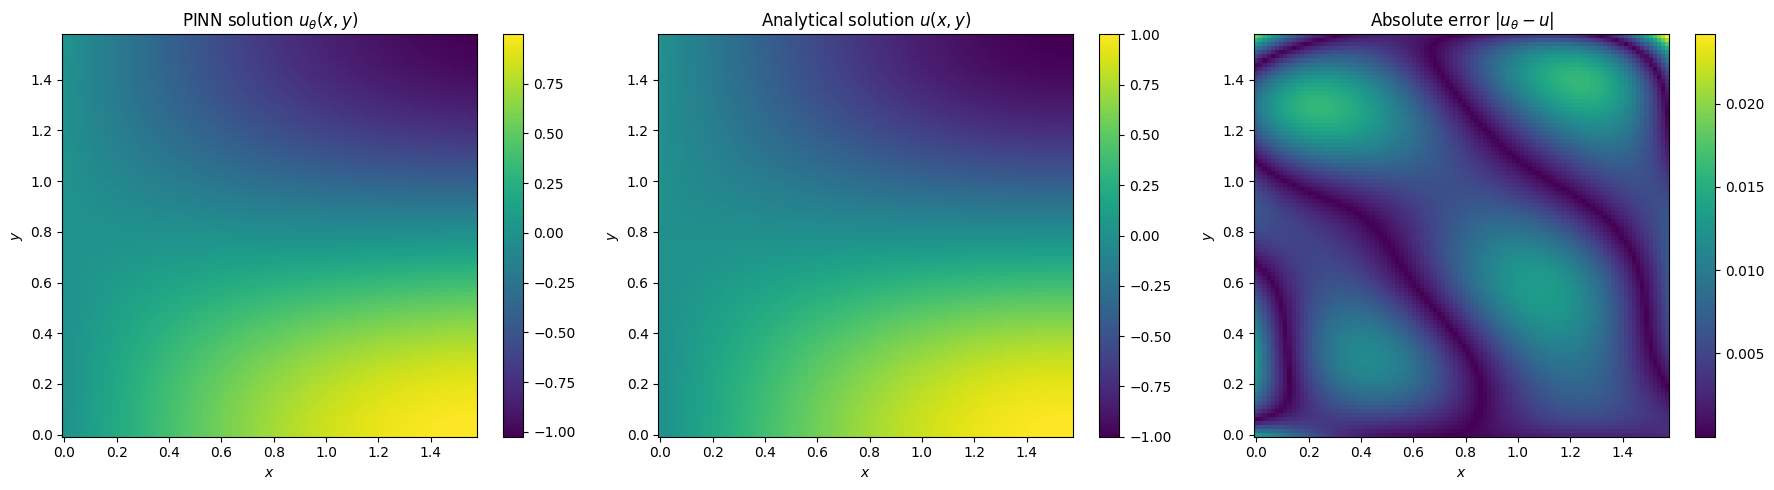

In [75]:
# ============================================================
# Визуализация решения задачи Пуассона
# ============================================================

model.eval()

# ============================================================
# Сетка для визуализации
# ============================================================

N_x_plot = 100
N_y_plot = 100

fs = 10

L = torch.pi / 2

x_plot = torch.linspace(0, L, N_x_plot).to(device)
y_plot = torch.linspace(0, L, N_y_plot).to(device)

# Создаем двумерную сетку (x, y)
X, Y = torch.meshgrid(
    x_plot,
    y_plot,
    indexing="ij"
)

# Превращаем сетку в список точек вида [x, y]
xy_plot = torch.cat(
    [
        X.reshape(-1, 1),
        Y.reshape(-1, 1)
    ],
    dim=1
).to(device)

# ============================================================
# Предсказание модели
# ============================================================

with torch.no_grad():
    u_pred = model(xy_plot)

# ============================================================
# Аналитическое решение
# u(x, y) = sin(x) cos(2y)
# ============================================================

with torch.no_grad():
    u_true = exact_solution(xy_plot)

# ============================================================
# Возвращаем значения к форме двумерной сетки
# ============================================================

U_pred = u_pred.reshape(N_x_plot, N_y_plot).detach().cpu().numpy()
U_true = u_true.reshape(N_x_plot, N_y_plot).detach().cpu().numpy()
U_error = np.abs(U_pred - U_true)

X_np = X.detach().cpu().numpy()
Y_np = Y.detach().cpu().numpy()


# ============================================================
# Тепловые карты: PINN, аналитическое решение, ошибка
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PINN solution
im0 = axes[0].pcolormesh(
    X_np,
    Y_np,
    U_pred,
    shading="auto"
)
axes[0].set_title(r"PINN solution $u_\theta(x,y)$")
axes[0].set_xlabel(r"$x$", fontsize=fs)
axes[0].set_ylabel(r"$y$", fontsize=fs)
axes[0].tick_params(axis="both", labelsize=fs)
fig.colorbar(im0, ax=axes[0])

# Exact solution
im1 = axes[1].pcolormesh(
    X_np,
    Y_np,
    U_true,
    shading="auto"
)
axes[1].set_title(r"Analytical solution $u(x,y)$")
axes[1].set_xlabel(r"$x$", fontsize=fs)
axes[1].set_ylabel(r"$y$", fontsize=fs)
axes[1].tick_params(axis="both", labelsize=fs)
fig.colorbar(im1, ax=axes[1])

# Absolute error
im2 = axes[2].pcolormesh(
    X_np,
    Y_np,
    U_error,
    shading="auto"
)
axes[2].set_title(r"Absolute error $|u_\theta - u|$")
axes[2].set_xlabel(r"$x$", fontsize=fs)
axes[2].set_ylabel(r"$y$", fontsize=fs)
axes[2].tick_params(axis="both", labelsize=fs)
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("poisson_equation_solution_maps.png", dpi=200)
plt.show()

# history

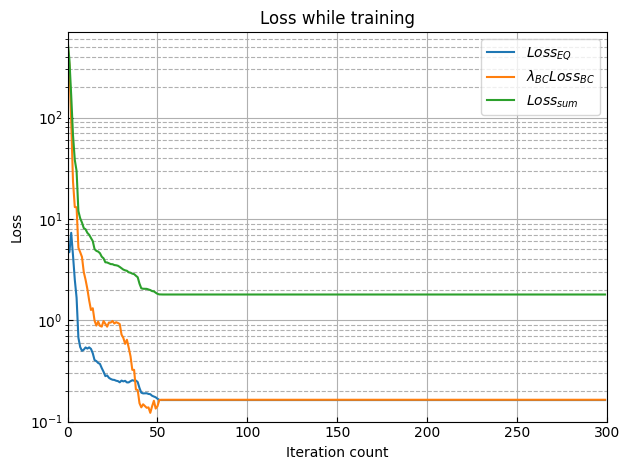

In [79]:
plt.plot(loss_eq, label=r'$Loss_{EQ}$')
plt.plot([1e3*i for i in loss_bc], label=r'$\lambda_{BC}Loss_{BC}$')
plt.plot(loss, label=r'$Loss_{sum}$')

ax=plt.gca()
ax.set_yscale('log')
plt.grid(which='major', linestyle='-')
plt.grid(which='minor', linestyle='--')
plt.xlim(0, len(loss))
plt.ylim(1e-1, max(loss) * 1.2)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
ax.tick_params(axis='both',direction='in')

plt.legend(fontsize=fs)
plt.xlabel('Iteration count', fontsize=fs)
plt.ylabel('Loss', fontsize=fs)
plt.title('Loss while training')
plt.tight_layout()
plt.savefig('history_harm.png')
plt.show()

In [80]:
mse_error = np.mean((U_pred - U_true) ** 2)
mae_error = np.mean(U_error)
max_error = np.max(U_error)

print(f"MSE error:      {mse_error:.6e}")
print(f"Mean abs error: {mae_error:.6e}")
print(f"Max abs error:  {max_error:.6e}")

MSE error:      5.288793e-05
Mean abs error: 6.150595e-03
Max abs error:  2.416801e-02


# Вывод коэффициентов модели ArticleLikeTLFN

In [81]:
def get_article_coefficients(model):
    """Извлекает обученные коэффициенты модели ArticleLikeTLFN.

    Для d=2 модель имеет вид:
        u_theta(x, y) =
            sum_p e_p * sigma(
                c_p1 * sigma(x - theta_p1)
              + c_p2 * sigma(y - theta_p2)
              - zeta_p
            )
    """
    with torch.no_grad():
        theta = model.theta.detach().cpu().numpy()
        c = model.c.detach().cpu().numpy()
        zeta = model.zeta.detach().cpu().numpy()
        e = model.e.detach().cpu().numpy()

    return theta, c, zeta, e

In [ ]:
from IPython.display import display, Markdown


def show_article_coefficients(model, digits=6):
    """
    Красиво выводит коэффициенты ArticleLikeTLFN-модели.

    Для d = 2 модель имеет вид:
        u_theta(x, y) =
            sum_p e_p * sigma(
                c_p1 * sigma(x - theta_p1)
              + c_p2 * sigma(y - theta_p2)
              - zeta_p
            )
    """

    theta, c, zeta, e = get_article_coefficients(model)

    m, d = theta.shape

    rows = []

    for p in range(m):
        row = {
            "p": p + 1,
        }

        for q in range(d):
            row[f"theta_p{q + 1}"] = theta[p, q]

        for q in range(d):
            row[f"c_p{q + 1}"] = c[p, q]

        row["zeta_p"] = zeta[p]

        if e.ndim == 2 and e.shape[1] == 1:
            row["e_p"] = e[p, 0]
        else:
            for r in range(e.shape[1]):
                row[f"e_p{r + 1}"] = e[p, r]

        rows.append(row)

    coeffs_df = pd.DataFrame(rows)

    display(Markdown("### Коэффициенты обученной модели ArticleLikeTLFN"))

    styled_df = (
        coeffs_df.style
        .format(precision=digits)
        .hide(axis="index")
        .set_caption("Параметры аппроксимирующей сети")
    )

    display(styled_df)

    return coeffs_df

In [82]:
res = show_article_coefficients(model)

### Коэффициенты обученной модели ArticleLikeTLFN

p,theta_p1,theta_p2,c_p1,c_p2,zeta_p,e_p
1,-3.508108,4.287508,-13.833034,81.998367,-13.515215,-56.400417
2,3.603553,2.733700,-1.017027,25.442585,0.069144,48.552975
3,1.739211,-1.969270,20.837549,18.717875,16.779867,-12.686440
4,-24.498257,0.863347,-13.654809,11.483099,-8.203115,5.512614
5,-5.957866,22.940495,-26.759068,-36.334095,-40.750015,20.758234
6,3.052748,-9.302560,22.736544,17.526922,16.907555,-6.584411
